## What is a Linear Regression model?

Linear Regression is one of the simplest Machine Learning models. It tries to fit  a straight line f(x) = ax + b to the data points by minimazing the loss function

C:\Users\hp\AppData\Local\Temp\ipykernel_20632\3854210748.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  a -= learning_rate * der_a


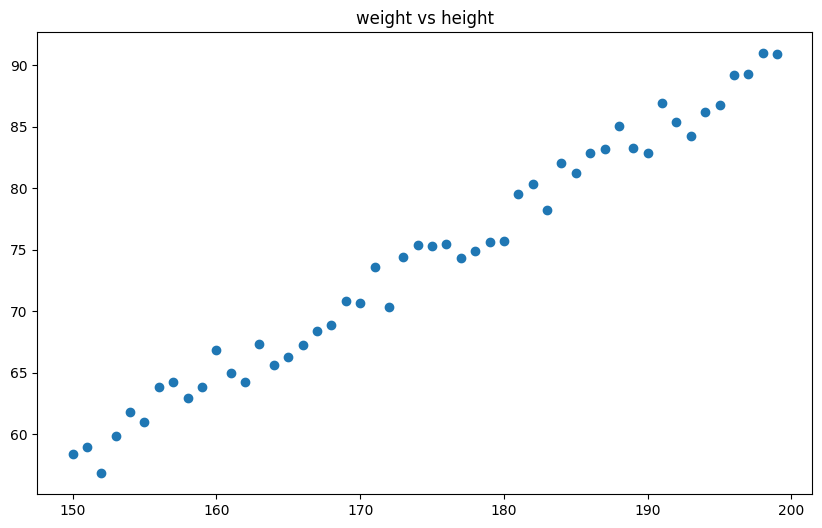

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a dataset of people measurements x - height(cm) y - weight(kg)
x = np.arange(150, 200)
y = x * 0.65 + np.random.rand(50) * 5 - 42

def mse(y_true, y_pred):
    """Computes root mean squared error between two vectors by subtracting predicted values 
    from actual values and squaring them"""
    return sum((y_true - y_pred)**2) / len(y_true)

def mse_derivative(y_true, y_pred):
    return 2 * (y_true - y_pred) / len(y_true)

def update_weights(a, b, x, y_true, learning_rate):
    """Update the weights in the direction of mse loss minimization"""
    # Calculate prediction
    y_pred = a*x + b

    # Calculate gradients
    der_a = 2 / len(x) * np.sum(x * (y_pred - y_true))
    der_b = 2 / len(x) * np.sum(y_pred - y_true)
    a -= learning_rate * der_a
    b -= learning_rate * der_b
    return (a, b)

def lin_reg(x, y_true, n_epochs, learning_rate=1e-5):
    a = 1
    b = 1

    for i in range(n_epochs):
        a, b = update_weights(a, b, x, y_true, learning_rate)
        
        # Print progress every 200 epochs
        if i % 200 == 0:
            y_pred = a*x + b
            error = mse(y_true, y_pred)
            print(f"Epoch {i:4d} | MSE: {error:.4f} | a={a:.4f}, b={b:.4f}")

    return [a, b]

fig, ax = plt.subplots(figsize=(10, 6))
plt.title("weight vs height")
ax.scatter(x, y)

# Train the Linear regression model with a smaller learning rate
a, b = lin_reg(x, y, 1000, learning_rate=1e-5)
y_pred = a*x + b

print(f"\nFinal parameters: a={a:.4f}, b={b:.4f}")

# Plot the prediction
ax.plot(x, y_pred, color="g", linewidth=2, label=f'y = {a:.2f}x + {b:.2f}')
ax.legend()
plt.show()